*This mathematical model and its corresponding code have been modified by **Jafar Namdar**, Faculty at Eli Broad College of Business, MSU, solely for teaching purposes — specifically to introduce undergraduate Supply Chain Management students to supply chain network design. The original model and notebook were created by the Gurobi team.*

**Modifications include:** parameter adjustments, added/removed constraints, revised objective function, updated widgets, incorporated inventory, shortage, and expanded service level reporting.

**Disclaimer:** This material is intended for educational use only and should not be used for live supply chain operations.

**Original sources:**
- [Gurobi Jupyter model example](https://www.gurobi.com/jupyter_models/supply-network-design/)  
- [Google Colab version](https://colab.research.google.com/github/Gurobi/modeling-examples/blob/master/supply_network_design/supply_network_design_2.ipynb#scrollTo=M9VacUIplKl-)

# 🎮 Network Rescue: The UK Distribution Challenge

## Your mission
You are a consulting team for **Albion Materials Ltd.**, which ships product from **2 factories** (Liverpool, Brighton) to **6 customers** (C1–C6), either directly or through **depots**. The company can choose which depots to use and whether to **expand Birmingham** by 20,000 tons.

The model in this notebook finds the **cheapest network** (lowest total cost) for any set of inputs you give it. Your job is to use it to answer one big question:

> **How should the network be designed when things can go wrong?**

## How the game works

| Step | What you do |
|---|---|
| 🏭 **Scenario 1 — Network Design** | Understand the best network today |
| ⚡ **Scenario 2 — Disruption Risk** | See what happens when a depot or factory fails |
| 🎲 **Scenario 3 — Planning With vs. Without Risk** | See how decisions change when risk is included |
| 📈 **Scenario 4 — Demand Uncertainty** | See which decisions hold up if demand is lower or higher |
| 🧩 **Your pick** | Choose **2 elective questions** from the menu |
| 💡 **Strategy** | Recommend 2–3 strategies to the COO |
| 🎤 **Present** | 7–8 minutes in class |

- **Required questions (R)** are answered by every team.
- **Elective questions (E)** are chosen by your team (pick 2). Different teams pick different ones, so presentations stay interesting.
- The presentation guide and grading rubric are right below.

In [ ]:
#@title Setup (runs automatically)
import importlib.util, subprocess, sys
if importlib.util.find_spec('gurobipy') is None:   # needed on Colab only
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gurobipy'], capture_output=True)

In [ ]:
#@title Answer boxes (runs automatically)
import ipywidgets as w, base64, datetime
from IPython.display import display
ANSWERS = {}
_box_layout = w.Layout(width='100%', height='140px')
team_name = w.Text(placeholder='Team name', description='Team:', layout=w.Layout(width='60%'))
team_members = w.Text(placeholder='Names of all members', description='Members:', layout=w.Layout(width='90%'))
def ask(qid, template='', height='140px'):
    """Show a text box for question qid and remember the answer."""
    box = w.Textarea(value=template, placeholder='Type your answer here…',
                     layout=w.Layout(width='100%', height=height))
    ANSWERS[qid] = box
    display(w.VBox([w.HTML(f"<b>✏️ Your answer ({qid}):</b>"), box]))

In [ ]:
#@title Team info
display(w.VBox([team_name, team_members]))

---
# 🎤 Presentation (7–8 minutes)

Use **at most 6 slides**:

1. **Our recommendation** (say the answer first)
2. **Scenario 1:** today's best network, with the network picture
3. **Scenarios 2 & 3:** what disruption does, and how risk changes the decision
4. **Scenario 4:** what holds up when demand changes
5. **Our 2 electives:** the most interesting finding
6. **Strategies:** 2–3 strategies with numbers

Every team member speaks. Expect 2 minutes of questions after.

**Submit (one per team):** your answers file (use the download button at the end of this page) and your slides.

---
# 📊 Grading Rubric (50 points)

| Part | Points | Full credit looks like |
|---|---|---|
| Scenario 1 — Network Design (R1.1–R1.2) | 5 | Correct cost, depots, and expansion; utilization calculated; bottleneck explained |
| Scenario 2 — Disruption Risk (R2.1–R2.2) | 5 | Table complete and correct; value of a backup depot calculated and explained |
| Scenario 3 — With vs. Without Risk (R3.1–R3.2) | 5 | Changes in decisions identified; clear reason why ignoring risk is misleading |
| Scenario 4 — Demand Uncertainty (R4.1–R4.2) | 5 | Table complete; decisions that stay vs. change identified; cost of being locked explained |
| Electives (2 × 5) | 10 | Correct numbers and a clear "so what" for the company |
| Strategy (RS) | 8 | 2–3 realistic strategies, each backed by a scenario result and its cost or trade-off |
| Presentation — story and clarity | 5 | Recommendation first, logical flow, easy to follow |
| Presentation — evidence and visuals | 5 | Numbers and network pictures support every claim; clean slides |
| Presentation — time, teamwork, Q&A | 2 | Within 7–8 minutes, everyone speaks, good answers to questions |
| **Total** | **50** | |

*For each question, about half the points are for correct numbers and half for the explanation.*

---
# 📘 The Problem

**Albion Materials Ltd.** makes one product at **2 factories** and sells it to **6 customers**. Product can go **through a depot** (factory → depot → customer) or **directly** (factory → customer). Every shipping lane has a cost per ton, and each depot costs money to open.

The catch: facilities are not perfectly **reliable**. A depot with 0.90 reliability only delivers 90% of its capacity on average.

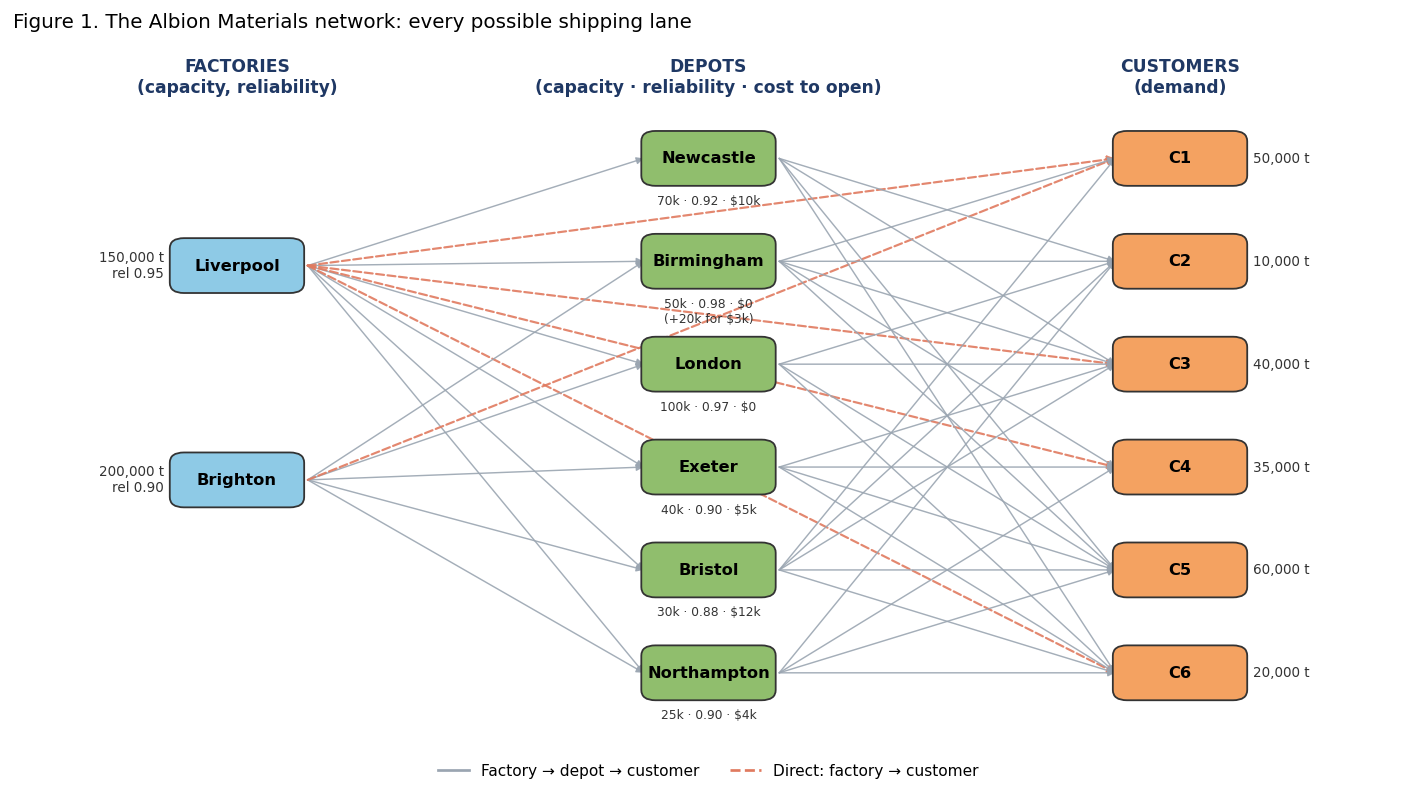

### What the model does

The model is an **optimization model**: you give it the data, and it finds the **cheapest possible network** that respects every capacity. It is the engine you will use to test your ideas.

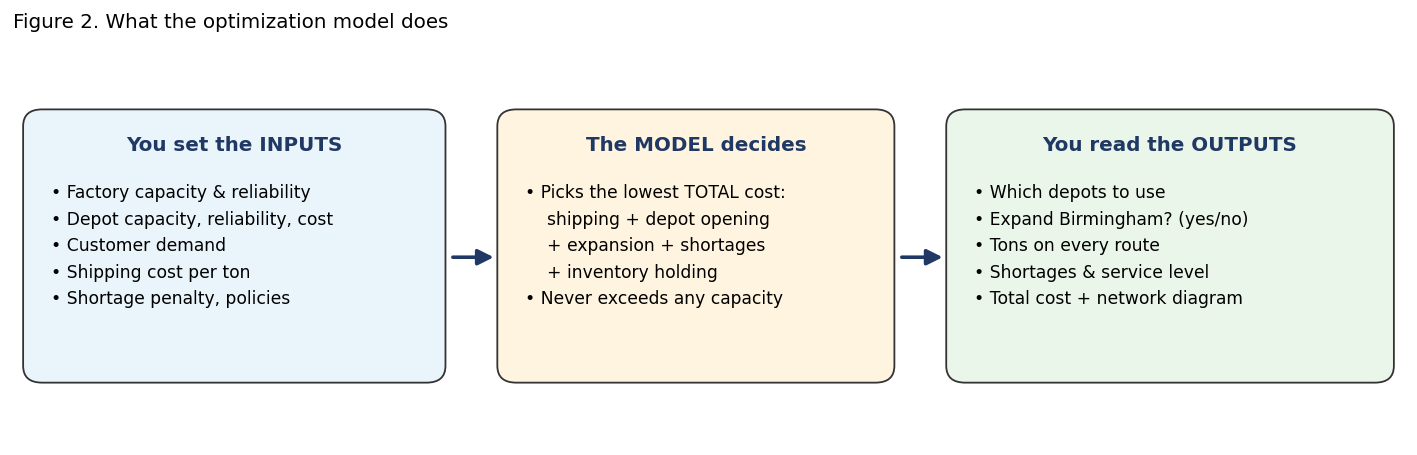

### The data

**Factories**

| Factory | Capacity (tons) | Reliability | Effective capacity |
|---|---|---|---|
| Liverpool | 150,000 | 0.95 | 142,500 |
| Brighton | 200,000 | 0.90 | 180,000 |

**Depots** (Birmingham can be expanded by 20,000 tons for \$3,000)

| Depot | Capacity (tons) | Reliability | Effective capacity | Cost to open |
|---|---|---|---|---|
| Newcastle | 70,000 | 0.92 | 64,400 | \$10,000 |
| Birmingham | 50,000 | 0.98 | 49,000 | \$0 (free to use) |
| London | 100,000 | 0.97 | 97,000 | \$0 (free to use) |
| Exeter | 40,000 | 0.90 | 36,000 | \$5,000 |
| Bristol | 30,000 | 0.88 | 26,400 | \$12,000 |
| Northampton | 25,000 | 0.90 | 22,500 | \$4,000 |

**Customers** (total demand 215,000 tons; each ton not delivered costs a \$5 penalty)

| Customer | C1 | C2 | C3 | C4 | C5 | C6 |
|---|---|---|---|---|---|---|
| Demand (tons) | 50,000 | 10,000 | 40,000 | 35,000 | 60,000 | 20,000 |

**Shipping cost (\$ per ton)** — a "–" means the lane does not exist.

| From → To | Newcastle | Birmingham | London | Exeter | Bristol | Northampton | C1 | C2 | C3 | C4 | C5 | C6 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| **Liverpool** | 0.5 | 0.5 | 1.0 | 0.2 | 0.6 | 0.4 | 1.0 | – | 1.5 | 2.0 | – | 1.0 |
| **Brighton** | – | 0.3 | 0.5 | 0.2 | 0.4 | 0.3 | 2.0 | – | – | – | – | – |
| **Newcastle** | | | | | | | – | 1.5 | 0.5 | – | 1.5 | 1.0 |
| **Birmingham** | | | | | | | 1.0 | 0.5 | 0.5 | 1.0 | 0.5 | – |
| **London** | | | | | | | – | 1.5 | 2.0 | – | 0.5 | 1.5 |
| **Exeter** | | | | | | | – | – | 0.2 | 1.5 | 0.5 | 1.5 |
| **Bristol** | | | | | | | 1.2 | 0.6 | 0.5 | – | 0.3 | 0.8 |
| **Northampton** | | | | | | | – | 0.4 | – | 0.5 | 0.6 | 0.9 |

*Want to see the math? It is in the Appendix at the end of this notebook (optional).*

## Key terms (read once)

- **Effective capacity** = capacity × reliability. A depot with 50,000 tons capacity and 0.98 reliability can really handle 49,000 tons.
- **Utilization** = tons shipped ÷ effective capacity.
- **Shortage** = demand that is not delivered. Each ton short costs a penalty (\$5/ton by default).
- **Service level** = % of a customer's demand that is not short.

## 🔄 Two rules
1. **Reset before every run.** Click the orange **Reset to baseline** button under the control panel. Then change **only** what the question says.
2. **Do not change** the inventory cap (20,000) or shortage cost (\$5) unless a question tells you to.

## 💾 Save your answers
Type your answers in the boxes under each question. **Nothing is saved automatically.** Before you close the page, scroll to the end and click **Prepare my answers file**, then the download link. If the page times out, your answers are lost, so download often.

---
# 🚀 The Control Panel
The control panel is below. Open a panel, change a value, then click **Solve with Gurobi**. Click **Reset to baseline** to undo all changes.

*If you only see text and no panel, wait a few seconds or refresh the page.*

In [ ]:
#@title Network model and control panel (runs automatically)
# ==== Interactive Supply Network Experiments (Gurobi) ====
# Single-period network design with per-site inventory holding costs.
# Decides factory/depot opening/expansion, flows, shortages, and where to hold inventory.

#%pip install gurobipy

import pandas as pd
import gurobipy as gp
from gurobipy import GRB
from IPython.display import display, clear_output
import ipywidgets as w

import networkx as nx
import matplotlib.pyplot as plt

# Quiet Gurobi environment (no solver log or license banner on screen)
_env = gp.Env(empty=True)
_env.setParam('OutputFlag', 0)
_env.start()

# -----------------------------
# FIXED TRANSPORTATION ARCS & COSTS (do not edit in class)
# -----------------------------
arcs, cost = gp.multidict({
    ('Liverpool', 'Newcastle'): 0.5,
    ('Liverpool', 'Birmingham'): 0.5,
    ('Liverpool', 'London'): 1.0,
    ('Liverpool', 'Exeter'): 0.2,
    ('Liverpool', 'Bristol'): 0.6,
    ('Liverpool', 'Northampton'): 0.4,
    ('Liverpool', 'C1'): 1.0,
    ('Liverpool', 'C3'): 1.5,
    ('Liverpool', 'C4'): 2.0,
    ('Liverpool', 'C6'): 1.0,
    ('Brighton', 'Birmingham'): 0.3,
    ('Brighton', 'London'): 0.5,
    ('Brighton', 'Exeter'): 0.2,
    ('Brighton', 'Bristol'): 0.4,
    ('Brighton', 'Northampton'): 0.3,
    ('Brighton', 'C1'): 2.0,
    ('Newcastle', 'C2'): 1.5,
    ('Newcastle', 'C3'): 0.5,
    ('Newcastle', 'C5'): 1.5,
    ('Newcastle', 'C6'): 1.0,
    ('Birmingham', 'C1'): 1.0,
    ('Birmingham', 'C2'): 0.5,
    ('Birmingham', 'C3'): 0.5,
    ('Birmingham', 'C4'): 1.0,
    ('Birmingham', 'C5'): 0.5,
    ('London', 'C2'): 1.5,
    ('London', 'C3'): 2.0,
    ('London', 'C5'): 0.5,
    ('London', 'C6'): 1.5,
    ('Exeter', 'C3'): 0.2,
    ('Exeter', 'C4'): 1.5,
    ('Exeter', 'C5'): 0.5,
    ('Exeter', 'C6'): 1.5,
    ('Bristol', 'C1'): 1.2,
    ('Bristol', 'C2'): 0.6,
    ('Bristol', 'C3'): 0.5,
    ('Bristol', 'C5'): 0.3,
    ('Bristol', 'C6'): 0.8,
    ('Northampton', 'C2'): 0.4,
    ('Northampton', 'C4'): 0.5,
    ('Northampton', 'C5'): 0.6,
    ('Northampton', 'C6'): 0.9
})

# -----------------------------
# DEFAULT (EDITABLE) DATA
# -----------------------------
supply0 = {'Liverpool': 150000, 'Brighton': 200000}
through0 = {
    'Newcastle': 70000, 'Birmingham': 50000, 'London': 100000,
    'Exeter': 40000, 'Bristol': 30000, 'Northampton': 25000
}
opencost0 = {'Newcastle': 10000, 'Birmingham': 0, 'London': 0, 'Exeter': 5000, 'Bristol': 12000, 'Northampton': 4000}
demand0 = {'C1': 50000, 'C2': 10000, 'C3': 40000, 'C4': 35000, 'C5': 60000, 'C6': 20000}
shortcost0 = {'C1': 5, 'C2': 5, 'C3': 5, 'C4': 5, 'C5': 5, 'C6': 5}
factory_reliab0 = {'Liverpool': 0.95, 'Brighton': 0.90}
depot_reliab0   = {'Newcastle': 0.92, 'Birmingham': 0.98, 'London': 0.97, 'Exeter': 0.90, 'Bristol': 0.88, 'Northampton': 0.90}

# Per-unit holding costs (customer finished goods are most expensive)
hold_factory0  = {'Liverpool': 0.03, 'Brighton': 0.03}
hold_depot0    = {'Newcastle': 0.05, 'Birmingham': 0.05, 'London': 0.05,
                  'Exeter': 0.05, 'Bristol': 0.05, 'Northampton': 0.05}
hold_customer0 = {'C1': 0.10, 'C2': 0.10, 'C3': 0.10, 'C4': 0.10, 'C5': 0.10, 'C6': 0.10}

# Network-wide inventory CAP (maximum ending inventory, units)
total_inventory_target0 = 20000

# Global sets inferred from fixed arcs
factories = sorted({i for i,j in arcs if i not in {'Newcastle','Birmingham','London','Exeter','Bristol','Northampton'}})
depots    = sorted({'Newcastle','Birmingham','London','Exeter','Bristol','Northampton'})
customers = sorted({j for i,j in arcs if str(j).startswith('C')})

# -----------------------------
# Helper: build one row of widgets for each dict item
# -----------------------------
def make_number_grid(d: dict, is_int=True, minv=None, maxv=None):
    rows = {}
    for k, v in d.items():
        if is_int:
            wgt = w.IntText(value=int(v), description=str(k), layout=w.Layout(width='300px'))
            if minv is not None: wgt.min = minv
        else:
            # For reliabilities, use sliders 0..1
            if maxv == 1 and minv == 0:
                wgt = w.FloatSlider(value=float(v), min=0, max=1, step=0.01, description=str(k),
                                    readout_format='.2f', layout=w.Layout(width='400px'))
            else:
                wgt = w.FloatText(value=float(v), description=str(k), layout=w.Layout(width='300px'))
        rows[k] = wgt
    box = w.VBox(list(rows.values()))
    return rows, box

# Widgets for each data block
sup_rows,  sup_box   = make_number_grid(supply0, is_int=True, minv=0)
thr_rows,  thr_box   = make_number_grid(through0, is_int=True, minv=0)
open_rows, open_box  = make_number_grid(opencost0, is_int=True, minv=0)
dem_rows,  dem_box   = make_number_grid(demand0, is_int=True, minv=0)
sho_rows,  sho_box   = make_number_grid(shortcost0, is_int=True, minv=0)
frel_rows, frel_box  = make_number_grid(factory_reliab0, is_int=False, minv=0, maxv=1)
drel_rows, drel_box  = make_number_grid(depot_reliab0,   is_int=False, minv=0, maxv=1)

# Holding cost widgets + total inventory target
hf_rows, hf_box = make_number_grid(hold_factory0,  is_int=False)
hd_rows, hd_box = make_number_grid(hold_depot0,    is_int=False)
hc_rows, hc_box = make_number_grid(hold_customer0, is_int=False)
inv_target = w.IntText(value=total_inventory_target0, description='Total inv cap')

# Policy/structural controls
forced_open = w.SelectMultiple(
    options=depots, value=(),
    description='Force-open depots', layout=w.Layout(width='320px', height='140px')
)
depot_limit = w.IntSlider(value=4, min=1, max=len(depots), step=1, description='Max open depots')

expand_extra_cap = w.IntText(value=20000, description='Bham expansion +cap')
expand_cost = w.IntText(value=3000, description='Bham expand cost')
obj_shift_note = w.HTML("<i>(Objective constant shift kept; it doesn’t affect optimality.)</i>")

solve_btn = w.Button(description='Solve with Gurobi', button_style='success')
out = w.Output()

accordion = w.Accordion(children=[
    sup_box, frel_box,
    thr_box, drel_box,
    open_box,
    dem_box, sho_box,
    w.VBox([forced_open, depot_limit, expand_extra_cap, expand_cost, obj_shift_note]),
    w.VBox([hf_box, hd_box, hc_box, inv_target])
])
accordion.set_title(0, 'Factory Supply')
accordion.set_title(1, 'Factory Reliability (0–1)')
accordion.set_title(2, 'Depot Throughput')
accordion.set_title(3, 'Depot Reliability (0–1)')
accordion.set_title(4, 'Depot Opening Cost')
accordion.set_title(5, 'Customer Demand')
accordion.set_title(6, 'Shortage Cost per Unit')
accordion.set_title(7, 'Policy: forced open, depot limit, Birmingham expansion')
accordion.set_title(8, 'Inventory: holding costs + CAP')

# Visualization toggle
show_network = w.Checkbox(value=True, description='Show network diagram')
accordion.children = tuple(list(accordion.children) + [w.VBox([show_network])])
accordion.set_title(len(accordion.children)-1, 'Visualization')

# Reset button: restores every input to its default value
reset_btn = w.Button(description='Reset to baseline', button_style='warning', icon='undo')
def _reset_all(b=None):
    for rows, d0 in [(sup_rows, supply0), (thr_rows, through0), (open_rows, opencost0), (dem_rows, demand0),
                     (sho_rows, shortcost0), (frel_rows, factory_reliab0), (drel_rows, depot_reliab0),
                     (hf_rows, hold_factory0), (hd_rows, hold_depot0), (hc_rows, hold_customer0)]:
        for k, v in d0.items():
            rows[k].value = v
    inv_target.value = total_inventory_target0
    forced_open.value = ()
    depot_limit.value = 4
    expand_extra_cap.value = 20000
    expand_cost.value = 3000
    show_network.value = True
    out.clear_output()
    with out:
        print("All inputs reset to the baseline. Click 'Solve with Gurobi'.")
reset_btn.on_click(_reset_all)

display(accordion, w.HBox([solve_btn, reset_btn]), out)

# -----------------------------
# Build & solve model from widget values
# -----------------------------

def run_model():
    # Collect values
    supply      = {k: int(v.value)   for k,v in sup_rows.items()}
    through     = {k: int(v.value)   for k,v in thr_rows.items()}
    opencost    = {k: int(v.value)   for k,v in open_rows.items()}
    demand      = {k: int(v.value)   for k,v in dem_rows.items()}
    shortcost   = {k: int(v.value)   for k,v in sho_rows.items()}
    factory_rel = {k: float(v.value) for k,v in frel_rows.items()}
    depot_rel   = {k: float(v.value) for k,v in drel_rows.items()}
    forced      = list(forced_open.value)
    max_open    = int(depot_limit.value)
    extra_cap   = int(expand_extra_cap.value)
    exp_cost    = int(expand_cost.value)

    # Holding costs and inventory CAP
    holdF = {k: float(v.value) for k, v in hf_rows.items()}
    holdD = {k: float(v.value) for k, v in hd_rows.items()}
    holdC = {k: float(v.value) for k, v in hc_rows.items()}
    total_inventory_cap = int(inv_target.value)

    # Effective capacities by reliability
    eff_supply  = {f: supply[f] * factory_rel[f] for f in supply}
    eff_through = {d: through[d] * depot_rel[d] for d in through}

    m = gp.Model('SupplyNetworkDesign_Interactive', env=_env)

    # Variables
    flow     = m.addVars(arcs, obj=cost, name="flow")
    openvar  = m.addVars(depots, obj=opencost, vtype=GRB.BINARY, name="open")
    expand   = m.addVar(obj=exp_cost, vtype=GRB.BINARY, name="expand")
    shortage = m.addVars(customers, obj=shortcost, name="shortage")

    # Ending inventory at each tier
    invF = m.addVars(factories, name="invF", lb=0.0)
    invD = m.addVars(depots,    name="invD", lb=0.0)
    invC = m.addVars(customers, name="invC", lb=0.0)

    obj = (
        gp.quicksum(cost[i, j] * flow[i, j] for i, j in arcs) +
        gp.quicksum(opencost[d] * openvar[d] for d in depots) +
        exp_cost * expand +
        gp.quicksum(shortcost[c] * shortage[c] for c in customers) +
        gp.quicksum(holdF[f] * invF[f] for f in factories) +
        gp.quicksum(holdD[d] * invD[d] for d in depots) +
        gp.quicksum(holdC[c] * invC[c] for c in customers)
    )
    m.setObjective(obj, GRB.MINIMIZE)
    # Force-open chosen depots
    for d in forced:
        openvar[d].lb = 1

    # Objective constant shift (doesn't affect optimality)
    #m.objcon = -(opencost.get('Newcastle',0) + opencost.get('Exeter',0))

    # Add holding costs to the objective (on top of current objective terms)
    #m.setObjective(
   #     m.getObjective()
      #  + gp.quicksum(holdF[f] * invF[f] for f in factories)
     #   + gp.quicksum(holdD[d] * invD[d] for d in depots)
     #   + gp.quicksum(holdC[c] * invC[c] for c in customers),
     #   GRB.MINIMIZE
    #)

    # Constraints
    # Factories: outbound + ending_inv <= effective supply
    m.addConstrs((
        gp.quicksum(flow.select(f, '*'))  <= eff_supply[f]+invF[f]
        for f in factories
    ), name="factory_balance_with_inv")

    # Depots: inbound = outbound + ending_inv
    m.addConstrs((
        gp.quicksum(flow.select('*', d)) == gp.quicksum(flow.select(d, '*'))
        for d in depots
    ), name="depot_balance_with_inv")

    # Customers: inbound + shortage = demand + ending_inv  (correct sign)
    m.addConstrs((
        gp.quicksum(flow.select('*', c)) + shortage[c] == demand[c] - invC[c]
        for c in customers
    ), name="demand_with_inv")

    # Depot capacity tying to open decisions (Birmingham may expand)
    for d in depots:
        if d == 'Birmingham':
            continue
        m.addConstr(gp.quicksum(flow.select(d, '*')) <= eff_through[d] * openvar[d]+ invD[d], name=f"cap_{d}")

    # Birmingham: limit OUTBOUND (fixed bug)
    m.addConstr(
        gp.quicksum(flow.select('Birmingham', '*')) <= (eff_through['Birmingham'] + extra_cap * expand) * openvar['Birmingham']+ invD['Birmingham'],
        name="bham_cap"
    )

    # Limit how many depots can be open
    m.addConstr(openvar.sum() <= max_open, name="open_limit")

    # Network-wide inventory CAP (maximum)
    m.addConstr(
        gp.quicksum(invF.values()) + gp.quicksum(invD.values()) + gp.quicksum(invC.values()) <= total_inventory_cap,
        name="total_inventory_cap"
    )

    # Optimize
    m.optimize()

    result = {
        "status": m.Status,
        "objective": m.ObjVal if m.Status == GRB.OPTIMAL else None,
        "open_depots": [d for d in depots if m.Status == GRB.OPTIMAL and openvar[d].X > 0.5],
        "expand_birmingham": (m.Status == GRB.OPTIMAL and round(expand.X) == 1),
    }

    if m.Status == GRB.OPTIMAL:
        # Shortages
        sh = [(c, shortage[c].X) for c in customers if shortage[c].X > 1e-6]
        shortage_df = pd.DataFrame(sh, columns=['Customer','Shortage'])

        # Flows
        flows = [(i,j, flow[i,j].X) for (i,j) in arcs if flow[i,j].X > 1e-6]
        flow_df = pd.DataFrame(flows, columns=['From','To','Quantity']).sort_values(['From','To'])

        # Service levels per customer (Satisfied = Demand - Shortage - EndingInv)
        svc_rows = []
        tot_demand = 0.0
        tot_satisfied = 0.0
        for c in customers:
            dem = float(demand[c])
            shrt = float(shortage[c].X)
            endinv = float(invC[c].X)
            sat = max(dem - shrt - endinv, 0.0)
            sl = 1.0 - (shrt / dem) if dem > 0 else 1.0
            svc_rows.append((c, dem, sat, shrt, endinv, sl))
            tot_demand += dem
            tot_satisfied += sat
        service_df = pd.DataFrame(svc_rows, columns=['Customer','Demand','Satisfied','Shortage','EndInv','ServiceLevel'])
        overall_service_level = (tot_satisfied / tot_demand) if tot_demand > 0 else 1.0

        # Inventory report
        invF_df = pd.DataFrame([(f, invF[f].X, holdF[f]) for f in factories],
                               columns=['Location','EndInv','HoldCost'])
        invD_df = pd.DataFrame([(d, invD[d].X, holdD[d]) for d in depots],
                               columns=['Location','EndInv','HoldCost'])
        invC_df = pd.DataFrame([(c, invC[c].X, holdC[c]) for c in customers],
                               columns=['Location','EndInv','HoldCost'])

        invF_df['Tier'] = 'Factory'
        invD_df['Tier'] = 'Depot'
        invC_df['Tier'] = 'Customer'
        inventory_df = pd.concat([invF_df, invD_df, invC_df], ignore_index=True)
        total_end_inv = float(inventory_df['EndInv'].sum())

        return result, shortage_df, flow_df, service_df, overall_service_level, inventory_df, total_end_inv
    else:
        return result, None, None, None, None, None, None

def draw_network_diagram(flow_df, open_depots):
    """
    Draw a 3-tier supply chain diagram using NetworkX.
    - flow_df columns: From, To, Quantity (positive flows only)
    - open_depots: list of depot names that are open in the solution
    """
    if flow_df is None or flow_df.empty:
        print("No positive flows to plot.")
        return

    # --- Build tiers from fixed sets ---
    tier_lists = [factories, depots, customers]

    # --- Fixed layout positions ---
    pos = {}
    x_spacing = 3.0
    y_spacing = 1.5
    for col, tier_nodes in enumerate(tier_lists):
        for row, node in enumerate(tier_nodes):
            pos[node] = (col * x_spacing, -row * y_spacing)

    # --- Build graph ---
    G = nx.DiGraph()
    G.add_nodes_from(factories)
    G.add_nodes_from(depots)
    G.add_nodes_from(customers)

    # Prepare a product_flow DataFrame (rename Quantity→Flow)
    product_flow = flow_df.rename(columns={'Quantity': 'Flow'})[['From', 'To', 'Flow']]

    # Sanity check for missing nodes
    all_nodes = set(product_flow["From"]).union(product_flow["To"])
    defined_nodes = set(factories + depots + customers)
    missing = all_nodes - defined_nodes
    if missing:
        print("⚠️ Warning: Unassigned nodes in tiers:", missing)

    # Add edges
    for _, row in product_flow.iterrows():
        u, v, q = row["From"], row["To"], float(row["Flow"])
        G.add_edge(u, v, weight=q)

    # --- Visual styling ---
    node_colors = []
    for n in G.nodes():
        if n in factories:
            node_colors.append("#8ecae6")      # factories
        elif n in customers:
            node_colors.append("#f4a261")      # customers
        else:
            node_colors.append("#90be6d" if n in open_depots else "#adb5bd")  # depots

    # Edge width scaling by flow
    flows = [d['weight'] for _,_,d in G.edges(data=True)]
    fmin, fmax = (min(flows), max(flows)) if flows else (0, 1)
    def width_scale(x, lo=0.8, hi=6.0):
        if fmax == fmin:
            return (lo + hi) / 2.0
        return lo + (x - fmin) * (hi - lo) / (fmax - fmin)
    edge_widths = [width_scale(d['weight']) for _,_,d in G.edges(data=True)]

    # --- Draw ---
    plt.figure(figsize=(12, 6))
    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=node_colors, edgecolors="black")
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=16, width=edge_widths)

    # Edge labels (flows, rounded)
    edge_labels = {(u, v): f"{d['weight']:.0f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

    plt.title("3-Tier Supply Chain Network (positive flows)")
    plt.axis("off")
    plt.show()

@out.capture(clear_output=True)
def on_solve_clicked(b):
    try:
        res, shortage_df, flow_df, service_df, overall_sl, inventory_df, total_end_inv = run_model()
        if res["status"] == GRB.OPTIMAL:
            print(f"Optimal objective: {res['objective']:.2f}")
            print("Open depots:", res['open_depots'])
            print("Expand Birmingham?:", res['expand_birmingham'])

            # Service levels
            if service_df is not None and not service_df.empty:
                display(
                    service_df
                    .assign(ServiceLevelPct=lambda df: df['ServiceLevel']*100)
                    .style
                    .format({'Demand':'{:.0f}','Satisfied':'{:.0f}','Shortage':'{:.0f}','EndInv':'{:.0f}','ServiceLevel':'{:.2f}','ServiceLevelPct':'{:.2f}%'})
                    .set_caption("Customer Service Levels = Satisfied =1-  (Shortage/Demand)")
                )
                #print(f"Overall weighted service level: {overall_sl*100:.2f}%")
            else:
                print("No customers found.")

            # Shortages (nonzero only)
            if shortage_df is not None and not shortage_df.empty:
                display(shortage_df.style.format({'Shortage':'{:.0f}'}).set_caption("Shortages (nonzero)"))
            else:
                print("Shortages: none")

            # Positive flows
            if flow_df is not None and not flow_df.empty:
                display(flow_df.style.format({'Quantity':'{:.0f}'}).set_caption("Positive flows"))
            else:
                print("No positive flows (unexpected).")

            # Inventory placement
            if inventory_df is not None and not inventory_df.empty:
                display(
                    inventory_df
                    .sort_values(['Tier','Location'])
                    .style
                    .format({'EndInv':'{:.0f}','HoldCost':'{:.2f}'})
                    .set_caption(f"Ending Inventory by Location (Total = {total_end_inv:.0f})")
                )
            else:
                print("No ending inventory.")

            if show_network.value:
                draw_network_diagram(flow_df, res['open_depots'])
        else:
            print("Model did not reach OPTIMAL status. Status code:", res["status"])
    except gp.GurobiError as e:
        print("Gurobi error:", e)
    except Exception as e:
        print("Error:", e)

solve_btn.on_click(on_solve_clicked)
with out:
    print("Ready. Open a panel, change a value, and click 'Solve with Gurobi'.")

### Where to find things in the control panel

| To do this… | Open this panel |
|---|---|
| Make a depot fail | **Depot Reliability** → set that depot to 0.00 |
| Make a factory produce less | **Factory Reliability** |
| Change demand | **Customer Demand** |
| Ignore risk (everything works perfectly) | Set **every** slider in Factory Reliability and Depot Reliability to 1.00 |
| **Lock the network** (no new depots can be opened) | **Depot Opening Cost** → set Newcastle, London, and Bristol to **999999** |
| Change the depot limit, force a depot open, or change the expansion | **Policy** |

---
# 🏭 Scenario 1 — Network Design (Baseline)

**Setup:** Do **not** change anything. Just click **Solve with Gurobi**.

**R1.1 (Required).** What is the total cost? Which depots actually ship product? Is Birmingham expanded?

In [ ]:
#@title Answer box R1.1
ask('R1.1')

**R1.2 (Required).** For each depot that ships product, calculate its utilization (tons shipped ÷ effective capacity). *(For Birmingham, add the 20,000-ton expansion to its effective capacity if it is expanded.)* What do you notice, and what does it mean for the company?

In [ ]:
#@title Answer box R1.2
ask('R1.2')

---
# ⚡ Scenario 2 — Disruption Risk

**Setup:** Choose **one** disruption (write which one you picked):
- **Option A — Birmingham depot fire:** Depot Reliability → Birmingham = 0.00
- **Option B — Brighton factory strike:** Factory Reliability → Brighton = 0.20

Run it **two ways** (reset in between):
1. **Flexible:** apply only the disruption. The company can quickly open another depot.
2. **Locked:** apply the disruption **and** lock the network (Newcastle, London, Bristol opening cost = 999999). The company is stuck with today's depots.

**R2.1 (Required).** Fill in the table: total cost, change vs. baseline, and total shortage for Baseline, Flexible, and Locked. Which customers are hurt most?

In [ ]:
#@title Answer box R2.1
ask('R2.1', template='Disruption chosen (A = Birmingham fire / B = Brighton strike): \n\nRun       | Total cost | Change vs. baseline | Total shortage (tons) | Customers hurt\nBaseline  |            | —                   |                       |\nFlexible  |            |                     |                       |\nLocked    |            |                     |                       |\n\nWhich customers are hurt most:', height='230px')

**R2.2 (Required).** How much is **flexibility** worth (Locked cost − Flexible cost)? In one or two sentences, explain why it is worth a lot or very little for your disruption.

In [ ]:
#@title Answer box R2.2
ask('R2.2')

---
# 🎲 Scenario 3 — Planning With vs. Without Risk

**Setup:** Set **every** reliability slider (both factories and all six depots) to **1.00**. This is a plan that assumes nothing ever goes wrong. Compare it with the baseline (Scenario 1), which **includes** reliability risk.

**R3.1 (Required).** Which decisions change when risk is ignored? Look at: depots used, Birmingham expansion, and total cost.

In [ ]:
#@title Answer box R3.1
ask('R3.1')

**R3.2 (Required).** The "no risk" plan looks cheaper. Why is that misleading? What could happen to a company that plans this way?

In [ ]:
#@title Answer box R3.2
ask('R3.2')

---
# 📈 Scenario 4 — Demand Uncertainty

**Setup:** Demand next year is uncertain. Run three cases (reset in between). Enter these values in **Customer Demand**:

| Case | C1 | C2 | C3 | C4 | C5 | C6 |
|---|---|---|---|---|---|---|
| Low (−20%) | 40000 | 8000 | 32000 | 28000 | 48000 | 16000 |
| Base | 50000 | 10000 | 40000 | 35000 | 60000 | 20000 |
| High (+20%) | 60000 | 12000 | 48000 | 42000 | 72000 | 24000 |

Then run **High demand + Locked network** (opening cost 999999 for Newcastle, London, Bristol).

**R4.1 (Required).** Which decisions stay the **same** in all three cases, and which **change**? (Depots used, expansion, cost per ton = total cost ÷ total demand.)

In [ ]:
#@title Answer box R4.1
ask('R4.1', template='Case          | Total cost | Cost per ton | Depots shipping | Expand Bham?\nLow           |            |              |                 |\nBase          |            |              |                 |\nHigh          |            |              |                 |\nHigh + Locked |            |              |                 |\n\nSame in all cases:\nChanges:', height='230px')

**R4.2 (Required).** If demand turns out High but the network is Locked, how much extra does it cost compared with the flexible High plan? What does this tell you about committing to a network today?

In [ ]:
#@title Answer box R4.2
ask('R4.2')

---
# 🧩 Elective Questions — pick **2**

Pick any two. Reset to baseline before each one. Tell us which two you picked.

| # | Question | What to change |
|---|---|---|
| **E1 — Fewer depots** | Management wants to run only 2 depots. What does that cost, and which depot is dropped? | Policy → Max open depots = 2 |
| **E2 — Is the expansion worth it?** | What is the most the company should pay for the Birmingham expansion? | Policy → Bham expand cost = 20000, compare with baseline |
| **E3 — The political depot** | A politician wants Newcastle kept open. What does it cost and does it ship anything? | Policy → Force-open Newcastle |
| **E4 — What is a shortage worth?** | What happens if a shortage costs \$0? \$2? Why does this number matter? | Shortage Cost → all customers 0, then 2 |
| **E5 — Big customer grows** | C5 demand jumps 30%. How does the network adapt, and what does each extra ton cost? | Customer Demand → C5 = 78000 |
| **E6 — Protect the key customer** | During the Brighton strike, who gets shorted? Can you protect C5? | Brighton reliability 0.20, then also C5 shortage cost = 20 |
| **E7 — Worst case** | Birmingham fire **and** Brighton strike at the same time. How bad is it? | Birmingham depot 0.00 + Brighton factory 0.20 (try Flexible and Locked) |
| **E8 — Going green** | Limit Liverpool (not renewable) to about 50,000 tons. What does green cost? | Factory Supply → Liverpool = 52632 |

**Elective #1 — write which one (E1–E8) at the start of your answer.**

In [ ]:
#@title Answer box Elective 1
ask('Elective 1')

**Elective #2 — write which one (E1–E8) at the start of your answer.**

In [ ]:
#@title Answer box Elective 2
ask('Elective 2')

---
# 💡 Strategy (Required)

**RS.** Based on your scenarios, recommend **2 or 3 strategies** to make the network cheaper **and** safer. For each strategy, give (1) what to do, (2) which scenario result supports it, and (3) what it costs or what you give up.

*Ideas to get you started (you can use your own):* keep a backup depot ready, expand capacity, a second supplier or factory backup, protect key customers first, safety stock, flexible contracts with depots.

In [ ]:
#@title Answer box Strategy
ask('Strategy', height='230px')

---
# 💾 Download your answers
Click the button, then click the link that appears. Submit this file with your slides.

In [ ]:
#@title Download answers
dl_btn = w.Button(description='Prepare my answers file', button_style='primary', icon='download',
                  layout=w.Layout(width='260px'))
dl_out = w.HTML()
def _make_file(b=None):
    lines = ["NETWORK RESCUE — TEAM ANSWERS",
             f"Team: {team_name.value}", f"Members: {team_members.value}",
             f"Saved: {datetime.datetime.now():%Y-%m-%d %H:%M}", "=" * 60]
    for qid, box in ANSWERS.items():
        lines += ["", f"[{qid}]", box.value.strip() or "(no answer)"]
    data = base64.b64encode("\n".join(lines).encode("utf-8")).decode()
    fname = "Network_Rescue_" + ("".join(ch for ch in team_name.value if ch.isalnum()) or "team") + ".txt"
    try:                                   # Colab: use its built-in download
        from google.colab import files
        with open(fname, 'w', encoding='utf-8') as fh:
            fh.write("\n".join(lines))
        files.download(fname)
        dl_out.value = f'<b>✅ Download started: {fname}</b> (check your Downloads folder)'
        return
    except ImportError:
        pass
    dl_out.value = (f'<a download="{fname}" href="data:text/plain;base64,{data}" '
                    'style="font-size:16px;font-weight:bold;">⬇️ Click here to download your answers</a>'
                    ' <span style="color:#666">(click the button again after any change)</span>')
dl_btn.on_click(_make_file)
display(w.VBox([dl_btn, dl_out]))

---

# 📎 Appendix — The Mathematical Model (optional)

*Based on Example 20 in H. Paul Williams, Model Building in Mathematical Programming (5th ed.), extended with reliability, inventory, shortages, and a Birmingham expansion option.*

## Model Formulation

### Sets and Indices

$$
F = \{\text{Liverpool}, \text{Brighton}\} \quad \text{(factories)}
$$

$$
D = \{\text{Newcastle}, \text{Birmingham}, \text{London}, \text{Exeter}, \text{Bristol}, \text{Northampton}\} \quad \text{(depots)}
$$

$$
C = \{\text{C1}, \text{C2}, \text{C3}, \text{C4}, \text{C5}, \text{C6}\} \quad \text{(customers)}
$$

$$
A \subseteq (F \cup D) \times (D \cup C) \quad \text{(transport arcs)}
$$

$$
D_{\text{force}} \subseteq D \quad \text{(forced-open depots)}
$$

| Symbol | Description |
|--------|-------------|
| $$ c_{ij}$$ | Transport cost per unit from node \( i \) to node \( j \) |
| $$ s_f $$ | Nominal supply capacity of factory \( f \) |
| $$ r^F_f $$ | Reliability of factory \( f \) |
| $$ t_d $$ | Nominal throughput of depot \( d \) |
| $$ r^D_d $$ | Reliability of depot \( d \) |
| $$ q_c $$ | Demand of customer \( c \) |
| $$ \pi_c $$ | Shortage penalty per unit at customer \( c \) |
| $$ \alpha_d $$ | Opening cost of depot \( d \) |
| $$ h^F_f, h^D_d, h^C_c $$ | Holding costs per unit at factories, depots, customers |
| $$ \Delta $$ | Extra capacity if Birmingham expands |
| $$ \kappa $$ | Cost of expanding Birmingham |
| $$ M $$ | Maximum number of open depots |
| $$ I_{\max} $$ | Total ending inventory cap |

Effective capacities:
$$
S_f = s_f \cdot r^F_f, \quad T_d = t_d \cdot r^D_d
$$

### Decision Variables
- $$ x_{ij} \ge 0 $$: flow from \( i \) to \( j \)  
- $$y_d \in \{0,1\} $$: depot \( d \) is open  
- $$ z \in \{0,1\} $$: Birmingham expands  
- $$ s_c \ge 0 $$: shortage at customer \( c \)  
-  $$I^F_f, I^D_d, I^C_c \ge 0 $$: ending inventory at factories, depots, customers  

### Objective Function
$$
\begin{aligned}
\min \quad &
\sum_{(i,j) \in A} c_{ij} x_{ij}
+ \sum_{d \in D} \alpha_d y_d
+ \kappa z
+ \sum_{c \in C} \pi_c s_c \\
&+ \sum_{f \in F} h^F_f I^F_f
+ \sum_{d \in D} h^D_d I^D_d
+ \sum_{c \in C} h^C_c I^C_c
\end{aligned}
$$

### Constraints
**Factory capacity with inventory**:- Flow of goods from a factory must respect the sum of maximum capacity and inventory at that location.

$$\sum_{j: (f,j) \in A} x_{fj}  \le S_f +I^F_f\quad \forall f \in F$$


**Depot flow balance with inventory**: Whatever flows into depot must flow out ( depot cannot flow 1000 if it only receives 10)
$$
\sum_{i: (i,d) \in A} x_{id} = \sum_{j: (d,j) \in A} x_{dj} \quad \forall d \in D
$$

**Customer demand with shortage and inventory**: Flow of goods +inventory-shortage must meet customer demand (basically, demand minus inventory must be satisfied by flow and shortage).
$$
\sum_{i: (i,c) \in A} x_{ic} + s_c = q_c - I^C_c \quad \forall c \in C
$$

**Depot capacity (except Birmingham)**: Flow of each depot must respect its effective capacity (reliable capacity) and inventory.
$$
\sum_{j: (d,j) \in A} x_{dj} \le T_d  y_d+ I^D_d \, \quad \forall d \in D \setminus \{\text{Birmingham}\}
$$

**Birmingham capacity with expansion**:Flow of each depot must respect its effective capacity (reliable capacity) and inventory. But this is the only place that has the capability of increasing capacity
$$
\sum_{j: (\text{Birmingham}, j) \in A} x_{\text{Birmingham}, j} \le (T_{\text{Birmingham}} + \Delta z) \, y_{\text{Birmingham}}+I_{\text{Birmingham}}
$$

**Limit number of open depots**:The total number of depot cannot be larger than pre-specified number (e.g., M=4)
$$
\sum_{d \in D} y_d \le M
$$

**Forced-open depots**: Not mandatory and user can decide. Optional constraint.
$$
y_d = 1 \quad \forall d \in D_{\text{force}}
$$

**Total inventory cap**: Total amount of inventory can be held at the entire supply chan network.
$$
\sum_{f \in F} I^F_f + \sum_{d \in D} I^D_d + \sum_{c \in C} I^C_c \le I_{\max}
$$

